In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [12]:
# Convert Date
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    # Sort by date
    df = df.sort_values('Date')
    # Set index
    df.set_index('Date', inplace=True)
elif pd.api.types.is_datetime64_any_dtype(df.index) and df.index.name == 'Date':
    # If 'Date' is already a DatetimeIndex, just ensure it's sorted
    df = df.sort_index()
else:
    # If 'Date' is not a column but the index is named 'Date' (but not yet datetime type)
    # or if the index name is None and it could be converted to datetime.
    # This handles cases where set_index was run, but to_datetime on index itself was missed
    # or if index is just unnamed, but should be treated as date.
    try:
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()
    except Exception as e:
        print(f"Warning: Could not convert index to datetime: {e}")
        print("Please ensure 'Date' column or index is correctly structured.")

# Remove rows with NaT in the index
df = df[df.index.notna()]

df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-22,32.0,49.0,39.0,7122.0,227.0
2023-01-23,32.0,50.0,39.0,7280.0,181.0
2023-01-24,47.0,42.0,47.0,7433.0,175.0
2023-01-25,20.0,22.0,41.0,7538.0,180.0


In [4]:
df = df.interpolate()

/tmp/ipykernel_7283/221517839.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate()


In [5]:
target = 'Children in HHS Care'

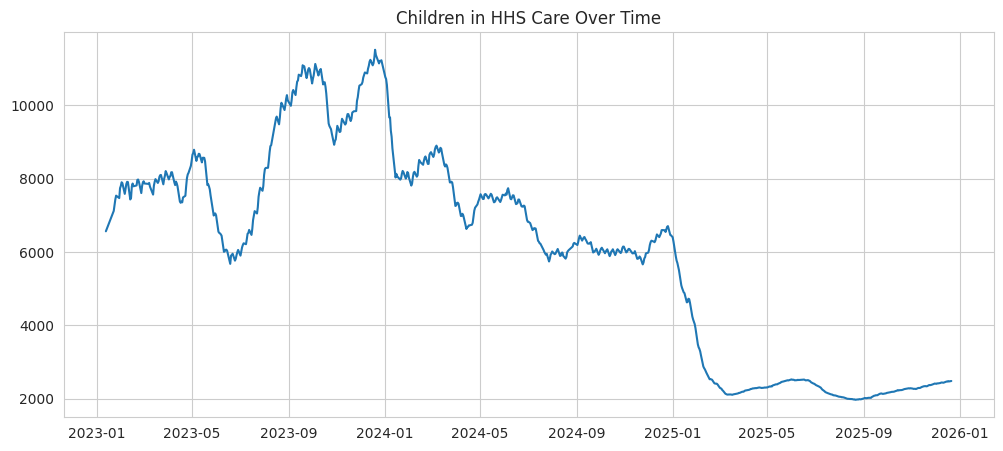

In [7]:
df[target] = df[target].replace(',', '', regex=True).astype(float)
plt.figure(figsize=(12,5))
plt.plot(df[target])
plt.title("Children in HHS Care Over Time")
plt.show()

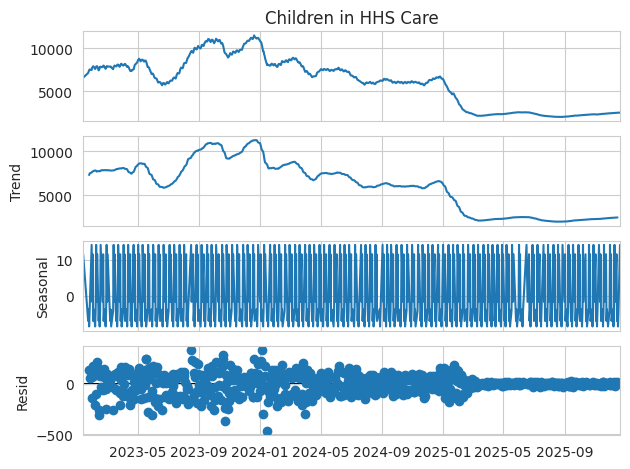

In [13]:
df[target] = df[target].interpolate()
decomposition = seasonal_decompose(df[target], model='additive', period=7)

decomposition.plot()
plt.show()

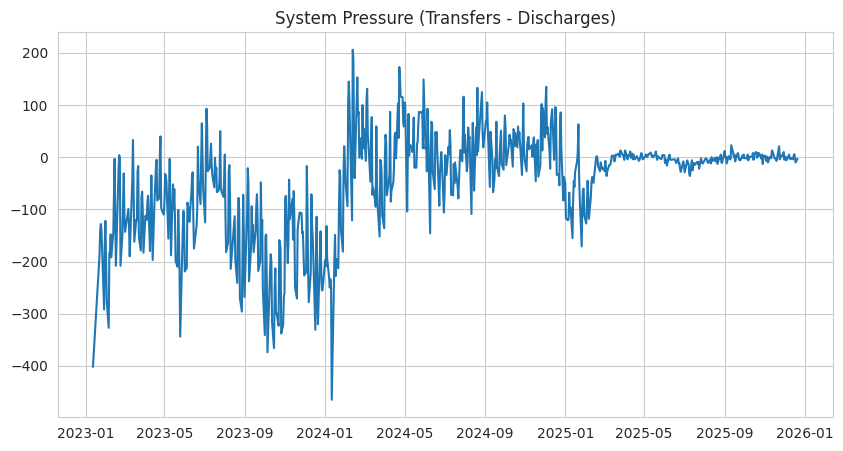

In [14]:
df['Net Pressure'] = df['Children transferred out of CBP custody'] - df['Children discharged from HHS Care']

plt.figure(figsize=(10,5))
plt.plot(df['Net Pressure'])
plt.title("System Pressure (Transfers - Discharges)")
plt.show()

In [15]:
for lag in [1, 7, 14]:
    df[f'lag_{lag}'] = df[target].shift(lag)

In [16]:
df['rolling_mean_7'] = df[target].rolling(7).mean()
df['rolling_mean_14'] = df[target].rolling(14).mean()

In [17]:
df = df.dropna()

In [18]:
train_size = int(len(df)*0.8)

train = df[:train_size]
test = df[train_size:]

MODEL 1 — ARIMA

In [19]:
model_arima = ARIMA(train[target], order=(5,1,0))
model_arima_fit = model_arima.fit()

arima_pred = model_arima_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

MODEL 2 — RANDOM FOREST

In [20]:
features = ['lag_1','lag_7','lag_14','rolling_mean_7','rolling_mean_14','Net Pressure']

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

MODEL EVALUATION

In [21]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    return mae, rmse, mape

print("ARIMA:", evaluate(y_test, arima_pred))
print("Random Forest:", evaluate(y_test, rf_pred))

ARIMA: (272.54803482117785, np.float64(323.05183556827393), nan)
Random Forest: (60.82725352112676, np.float64(83.7619968998345), np.float64(2.820529837359842))


/tmp/ipykernel_7283/2973751326.py:4: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((y_true - y_pred)/y_true))*100


VISUALIZE RESULTS

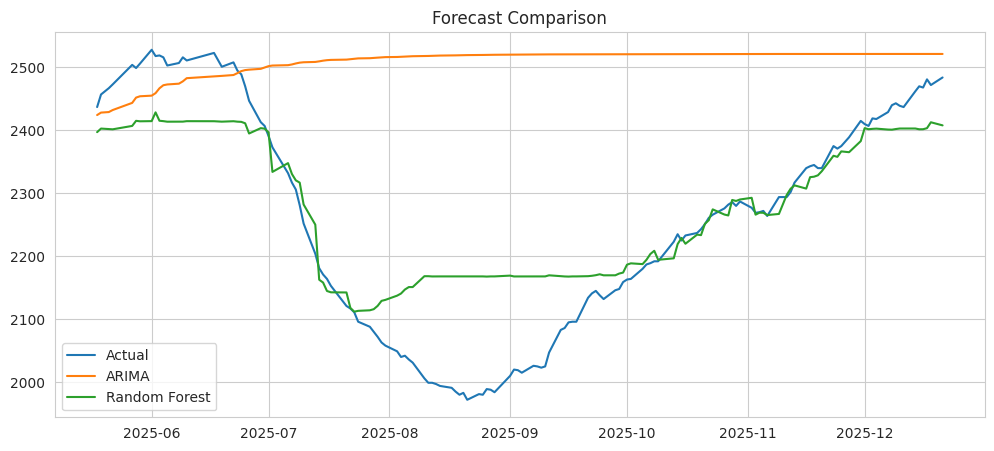

In [22]:
plt.figure(figsize=(12,5))
plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, arima_pred, label="ARIMA")
plt.plot(test.index, rf_pred, label="Random Forest")

plt.legend()
plt.title("Forecast Comparison")
plt.show()

In [23]:
future_steps = 7
future_pred = model_arima_fit.forecast(steps=future_steps)

print("Next 7 Days Forecast:")
print(future_pred)

Next 7 Days Forecast:
564    2424.306780
565    2428.216147
566    2429.065015
567    2432.285230
568    2443.623132
569    2452.043425
570    2454.138577
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


HHS care load shows clear trend + weekly pattern

Net pressure drives system stress

 ARIMA captures trend well

Random Forest captures complex relationships

Forecast helps predict overcrowding risk